In [1]:
from dataset import Mixed_CBCT_dataset

dataset = Mixed_CBCT_dataset(
    ["knee_cbct"], split="eval", out_res=512, dst_root="../data"
)
data = dataset[1]
# print(dataset.datasets[0].name_list)

mixed_dataset: ['knee_cbct']
CBCT_dataset, name: knee_cbct, split: eval, len: 6.
Loaded Z-lengths for 865 patients.


In [2]:
print(data["p_gt"].shape)
print(data["angles"])
print(data["points"].shape)
print(data["proj_points"].shape)
print(data["projs"].shape)

(1, 117964800)
[[ 2.78275352e-08]
 [-1.00000000e+00]]
(117964800, 3)
(2, 117964800, 2)
(2, 1, 512, 512)


In [ ]:
print(data["points"][5])
print(data["p_gt"][0, 5])
print(data["proj_points"][0, 5])

print(data["p_gt"][0, 50000000])

[-1.        -1.         0.8590998]
0.0
[-1.00000005  0.85909981]
0.0


In [4]:
print(data["image"].min())
print(data["image"].max())
print(data["image"].mean())
print(data["image"].shape)

0.0
5.4936495
0.09859698
(512, 512, 450)


In [5]:
from verify_projection import vector_splatting

generated_projs = vector_splatting(None, data["proj_points"], data["image"].flatten())

Running validation on cpu...
Processing view 1/2...
Processing view 2/2...


In [7]:
print(generated_projs[0].shape)

(512, 512)


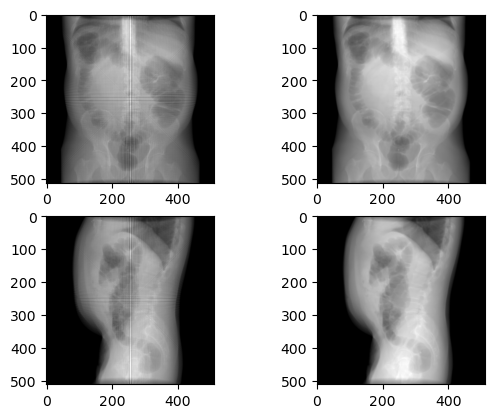

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(2, 2, 1)
plt.imshow(generated_projs[0], cmap="gray")
plt.subplot(2, 2, 2)
plt.imshow(data["projs"][0][0], cmap="gray")
plt.subplot(2, 2, 3)
plt.imshow(generated_projs[1], cmap="gray")
plt.subplot(2, 2, 4)
plt.imshow(data["projs"][1][0], cmap="gray")
plt.show()

In [ ]:
# test block loading
import numpy as np

data = np.load("../../block/1.3.6.1.4.1.9328.50.4.0172/block_0.npz")
print(data["arr_0"].shape)

(1835008,)


In [ ]:
# test block loading from .h5
import h5py


def read_h5_ct(path):
    with h5py.File(path, "r") as f:
        # 假设ct数据在'ct'键下
        image = f["ct"][:]
    return image


file = "/root/aicp-data/val_data/1.3.6.1.4.1.9328.50.4.0172/ct_xray_data.h5"

ct_data = read_h5_ct(file).transpose(2, 1, 0)
print(ct_data.shape)
shape = ct_data.shape
base = np.mgrid[: shape[0] // 4, : shape[1] // 4, : shape[2] // 4] * 4  # 3, 64 ^ 3

# print(base.shape)
block = base
print(block.shape)
print(block[:, 0].shape)

block = block.reshape(3, -1).transpose(1, 0)
print(block.shape)
print(block[:, 0].shape)
print(block[-1])
# print(ct_data[block[:, 0], block[:, 1], block[:, 2]].shape)

(512, 512, 450)
(3, 128, 128, 112)
(3, 128, 112)
(1835008, 3)
(1835008,)
[508 508 444]
